In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
doubs_data.shape

(2679, 62)

In [7]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnie'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff          4.0
1  871f82d61ffffff         12.0
2  871f82d61ffffff         12.0
3  871f82d4dffffff          1.0
4  871f82700ffffff          5.0


In [9]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnie'] == hexagone['id_compagnie']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnie', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnie id_caserne  distance
0  871f820aaffffff          4.0     840709       0.0
1  871f82d61ffffff         12.0     840704  0.005327
2  871f82d61ffffff         12.0     840704  0.005327
3  871f82d4dffffff          1.0     840698  0.039716
4  871f82700ffffff          5.0     840701  0.010387


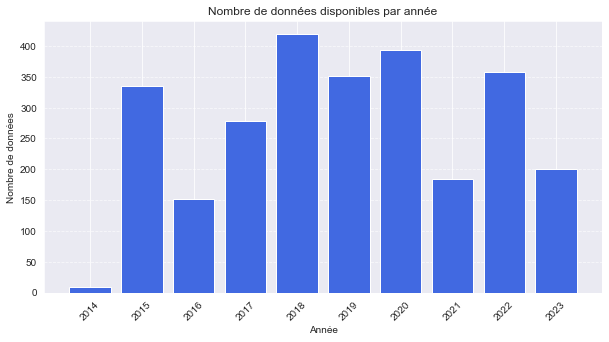

In [10]:
year_counts = doubs_data["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="royalblue")
plt.xlabel("Année")
plt.ylabel("Nombre de données")
plt.title("Nombre de données disponibles par année")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [11]:
print(year_counts)

2014.0      9
2015.0    335
2016.0    152
2017.0    278
2018.0    420
2019.0    351
2020.0    393
2021.0    184
2022.0    357
2023.0    200
Name: year, dtype: int64


In [12]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnie', 'id_caserne',
       'distance'],
      dtype='object')

In [13]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister',
       'id_compagnie', 'id_caserne', 'date_debut', 'date_fin', 'year', 'date', 'scale0', 'hour', 'month', 'weekday', 'distance'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [14]:
doubs_data.columns

Index(['hex_id', 'duree_minutes', 'geometry', 'centroid', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow'],
      dtype='object')

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

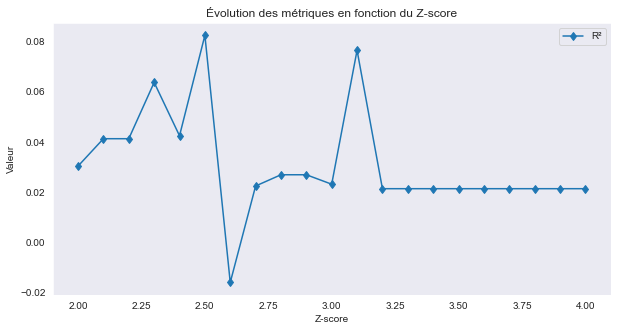

In [15]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

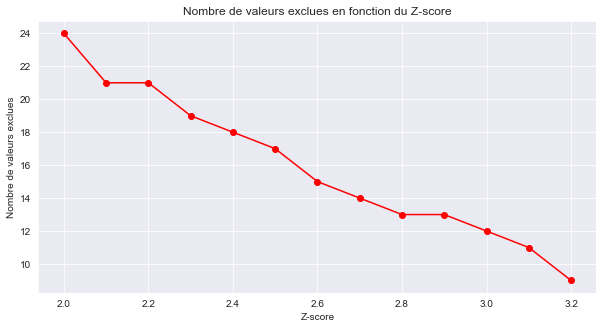

In [16]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

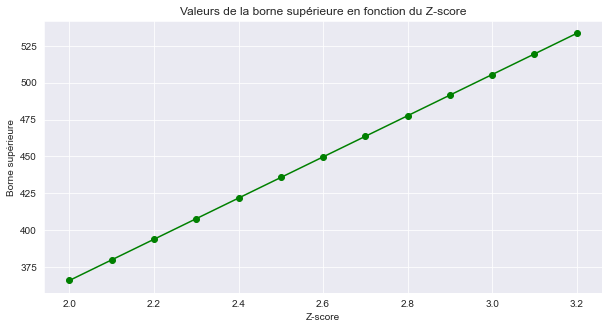

In [17]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [18]:
top_35_values = df['duree_minutes'].nlargest(35)

print(top_35_values)

1716    3885.850000
1199    3025.100000
1263    2753.933333
954     1725.383333
234     1667.683333
836     1629.883333
228     1625.983333
363     1500.500000
1112     920.333333
1341     531.866667
2583     530.733333
2590     510.183333
2853     504.333333
242      466.100000
2553     458.316667
160      443.816667
1931     437.516667
1173     435.516667
199      414.416667
2663     402.866667
505      398.400000
1804     373.866667
2419     371.916667
68       367.333333
1772     363.283333
260      359.183333
2778     358.000000
2767     357.716667
2816     355.216667
656      347.350000
0        345.533333
362      344.300000
937      342.533333
2297     331.250000
1009     326.916667
Name: duree_minutes, dtype: float64


In [19]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [20]:
doubs_data_filtered.columns

Index(['hex_id', 'duree_minutes', 'geometry', 'centroid', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow'],
      dtype='object')

In [21]:
doubs_data_clean = doubs_data_filtered.drop(columns=["z-score"], errors="ignore")

doubs_data_grouped = doubs_data_clean.groupby("hex_id").agg(
    {
        "duree_minutes": "mean",
        "NDVI": "mean",
        "NDMI": "mean",
        "NDBI": "mean",
        "NDSI": "mean",
        "NDWI": "mean",
        "PasDeRoute": "mean",
        "motorway": "mean",
        "primary": "mean",
        "secondary": "mean",
        "tertiary": "mean",
        "path": "mean",
        "population": "mean",
        "elevation": "mean",
        "foret_encoder": "mean",
        "highway_encoder": "mean",
        "PasDeforet": "mean",
        "Châtaignier": "mean",
        "Chênes décidus": "mean",
        "Conifères": "mean",
        "Douglas": "mean",
        "Feuillus": "mean",
        "Hêtre": "mean",
        "Mixte": "mean",
        "Mélèze": "mean",
        "NC": "mean",
        "NR": "mean",
        "Peuplier": "mean",
        "Pin autre": "mean",
        "Pin laricio, pin noir": "mean",
        "Pin maritime": "mean",
        "Pin sylvestre": "mean",
        "Pins mélangés": "mean",
        "Robinier": "mean",
        "Sapin, épicéa": "mean",
        "water": "mean",
        "tree": "mean",
        "grass": "mean",
        "crops": "mean",
        "shrub": "mean",
        "flooded": "mean",
        "built": "mean",
        "bare": "mean",
        "snow": "mean"
    }
)

doubs_data_grouped = doubs_data_grouped.reset_index()

doubs_data_grouped["geometry"] = doubs_data.groupby("hex_id")["geometry"].first().values

print(doubs_data_grouped.head())

            hex_id  duree_minutes      NDVI      NDMI      NDBI      NDSI  \
0  871f80492ffffff     117.325000  0.720443  0.145452 -0.145452 -0.593620   
1  871f80493ffffff      79.483333  0.739361  0.162564 -0.162564 -0.599609   
2  871f80498ffffff     160.133333  0.785204  0.193932 -0.193932 -0.627573   
3  871f8049affffff      65.383333  0.778036  0.189057 -0.189057 -0.623016   
4  871f8049cffffff      89.400000  0.751272  0.175163 -0.175163 -0.599002   

       NDWI  PasDeRoute  motorway   primary  ...     water       tree  \
0 -0.672639   96.116627       0.0  0.703783  ...  0.012568  35.314817   
1 -0.688388   95.966830       0.0  0.238723  ...  0.000000  49.805252   
2 -0.728378   97.701871       0.0  0.000000  ...  0.000000  86.613086   
3 -0.721208   96.609318       0.0  0.000000  ...  0.000000  48.172799   
4 -0.693667   96.231629       0.0  0.000000  ...  0.050245  40.723527   

       grass     crops     shrub   flooded     built  bare  snow  \
0  25.637803  0.062838  4.7002

In [22]:
doubs_data_grouped.columns

Index(['hex_id', 'duree_minutes', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry'],
      dtype='object')

In [23]:
crs_original = doubs_data_filtered.crs
if crs_original is None:
    raise ValueError(" Le GeoDataFrame doubs_data_filtered n'a pas de CRS défini !")

hexagones_uniques = doubs_data_grouped["hex_id"].unique()
hex_train, hex_test = train_test_split(hexagones_uniques, test_size=0.2, random_state=42)

doubs_train = doubs_data_grouped[doubs_data_grouped["hex_id"].isin(hex_train)].copy()
doubs_test = doubs_data_grouped[doubs_data_grouped["hex_id"].isin(hex_test)].copy()

doubs_train = gpd.GeoDataFrame(doubs_train, geometry="geometry", crs=crs_original)
doubs_test = gpd.GeoDataFrame(doubs_test, geometry="geometry", crs=crs_original)

assert doubs_train.crs == crs_original, " CRS de doubs_train différent de doubs_data_filtered !"
assert doubs_test.crs == crs_original, "️ CRS de doubs_test différent de doubs_data_filtered !"

print(f" Nombre d'hexagones uniques dans le train : {doubs_train['hex_id'].nunique()}")
print(f" Nombre d'hexagones uniques dans le test  : {doubs_test['hex_id'].nunique()}")
print(f" Intersection des hex_id entre train et test : {len(set(doubs_train['hex_id']).intersection(set(doubs_test['hex_id'])))}")
print(" CRS correctement appliqué !")

 Nombre d'hexagones uniques dans le train : 501
 Nombre d'hexagones uniques dans le test  : 126
 Intersection des hex_id entre train et test : 0
 CRS correctement appliqué !


In [24]:
doubs_train = doubs_train.to_crs(epsg=2154)
doubs_test = doubs_test.to_crs(epsg=2154)

doubs_train["centroid"] = doubs_train.geometry.centroid
doubs_test["centroid"] = doubs_test.geometry.centroid

train_centroids = doubs_train.set_index("hex_id")["centroid"]

def trouver_6_proches(hex_id_source, centroid_source):
    lignes = []

    for hex_id_cible, centroid_cible in train_centroids.items():
        if hex_id_cible != hex_id_source:
            distance = LineString([centroid_source, centroid_cible]).length

            if distance <= 4000:
                lignes.append((hex_id_cible, distance))

    lignes_tries = sorted(lignes, key=lambda x: x[1])[:6]

    return [hex_id for hex_id, _ in lignes_tries]

print("Traitement de doubs_train...")
doubs_train["proches_voisins"] = [
    trouver_6_proches(row["hex_id"], row["centroid"])
    for _, row in tqdm(doubs_train.iterrows(), total=len(doubs_train))
]

print("Traitement de doubs_test...")
doubs_test["proches_voisins"] = [
    trouver_6_proches(row["hex_id"], row["centroid"])
    for _, row in tqdm(doubs_test.iterrows(), total=len(doubs_test))
]

print(doubs_train[["hex_id", "proches_voisins"]].head())
print(doubs_test[["hex_id", "proches_voisins"]].head())

  0%|          | 2/501 [00:00<00:26, 18.89it/s]

Traitement de doubs_train...


  2%|▏         | 2/126 [00:00<00:06, 19.77it/s]

Traitement de doubs_test...


100%|██████████| 126/126 [00:04<00:00, 30.70it/s]

            hex_id                                    proches_voisins
0  871f80492ffffff                 [871f8286cffffff, 871f80493ffffff]
1  871f80493ffffff  [871f80492ffffff, 871f8049effffff, 871f8286cff...
3  871f8049affffff                 [871f8049effffff, 871f82869ffffff]
4  871f8049cffffff                                  [871f8049effffff]
5  871f8049effffff  [871f8049affffff, 871f80493ffffff, 871f8049cff...
             hex_id                                    proches_voisins
2   871f80498ffffff  [871f8049cffffff, 871f8049effffff, 871f8049aff...
10  871f804d8ffffff                 [871f804deffffff, 871f804d9ffffff]
24  871f8079affffff  [871f806b4ffffff, 871f80798ffffff, 871f82b69ff...
29  871f82006ffffff                 [871f82031ffffff, 871f82000ffffff]
30  871f82008ffffff                 [871f8200dffffff, 871f8200affffff]


In [25]:
doubs_train["nb_voisins"] = doubs_train["proches_voisins"].apply(len)
doubs_test["nb_voisins"] = doubs_test["proches_voisins"].apply(len)

print(doubs_train[["hex_id", "nb_voisins"]].head())
print(doubs_test[["hex_id", "nb_voisins"]].head())

print("Statistiques sur le nombre de voisins (train) :")
print(doubs_train["nb_voisins"].describe())

print("Statistiques sur le nombre de voisins (test) :")
print(doubs_test["nb_voisins"].describe())

            hex_id  nb_voisins
0  871f80492ffffff           2
1  871f80493ffffff           3
3  871f8049affffff           2
4  871f8049cffffff           1
5  871f8049effffff           3
             hex_id  nb_voisins
2   871f80498ffffff           3
10  871f804d8ffffff           2
24  871f8079affffff           5
29  871f82006ffffff           2
30  871f82008ffffff           2
Statistiques sur le nombre de voisins (train) :
count    501.000000
mean       2.894212
std        1.377965
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: nb_voisins, dtype: float64
Statistiques sur le nombre de voisins (test) :
count    126.000000
mean       2.944444
std        1.465909
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: nb_voisins, dtype: float64


In [26]:
def calculer_statistiques(hex_ids_voisins, df):
    voisins_df = df[df["hex_id"].isin(hex_ids_voisins)]

    statistiques = {
        "mean": voisins_df["duree_minutes"].mean(),
        "std": voisins_df["duree_minutes"].std(),
        "median": voisins_df["duree_minutes"].median(),
        "min": voisins_df["duree_minutes"].min(),
        "max": voisins_df["duree_minutes"].max(),
        "q1": voisins_df["duree_minutes"].quantile(0.25),
        "q3": voisins_df["duree_minutes"].quantile(0.75)
    }

    return statistiques

doubs_train[["mean", "std", "median", "min", "max", "q1", "q3"]] = doubs_train["proches_voisins"].apply(
    lambda voisins: pd.Series(calculer_statistiques(voisins, doubs_train))
)

doubs_test[["mean", "std", "median", "min", "max", "q1", "q3"]] = doubs_test["proches_voisins"].apply(
    lambda voisins: pd.Series(calculer_statistiques(voisins, doubs_train))
)

print(doubs_train[["hex_id", "mean", "std", "median", "min", "max", "q1", "q3"]].head())
print(doubs_test[["hex_id", "mean", "std", "median", "min", "max", "q1", "q3"]].head())

            hex_id        mean        std      median        min         max  \
0  871f80492ffffff   80.295833   1.149049   80.295833  79.483333   81.108333   
1  871f80493ffffff   98.773611  18.124586   97.887500  81.108333  117.325000   
3  871f8049affffff  138.952083  58.074091  138.952083  97.887500  180.016667   
4  871f8049cffffff   97.887500        NaN   97.887500  97.887500   97.887500   
5  871f8049effffff   78.088889  12.068903   79.483333  65.383333   89.400000   

           q1          q3  
0   79.889583   80.702083  
1   89.497917  107.606250  
3  118.419792  159.484375  
4   97.887500   97.887500  
5   72.433333   84.441667  
             hex_id        mean         std      median         min  \
2   871f80498ffffff   84.223611   16.859017   89.400000   65.383333   
10  871f804d8ffffff  178.775000  108.199123  178.775000  102.266667   
24  871f8079affffff   67.344283   39.643478   52.320833   38.975000   
29  871f82006ffffff   80.916667   28.873527   80.916667   60.500000

In [27]:
doubs_train.columns

Index(['hex_id', 'duree_minutes', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'centroid', 'proches_voisins', 'nb_voisins', 'mean', 'std', 'median',
       'min', 'max', 'q1', 'q3'],
      dtype='object')

In [28]:
features = doubs_train.drop(columns=["duree_minutes", "hex_id", "proches_voisins", 'geometry', 'centroid']).columns
target = "duree_minutes"

X_train = doubs_train[features]
y_train = doubs_train[target]
X_test = doubs_test[features]
y_test = doubs_test[target]

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R²: {r2}")

MSE: 2842.9445745439325
RMSE: 53.319270198905876
MAE: 38.03013847210551
R²: -0.42935622172658894


       feature  importance
40       built    0.080530
7      primary    0.057211
2         NDBI    0.048203
49          q1    0.047907
25          NR    0.044693
44        mean    0.043716
47         min    0.040754
35        tree    0.039937
4         NDWI    0.038902
11  population    0.036007


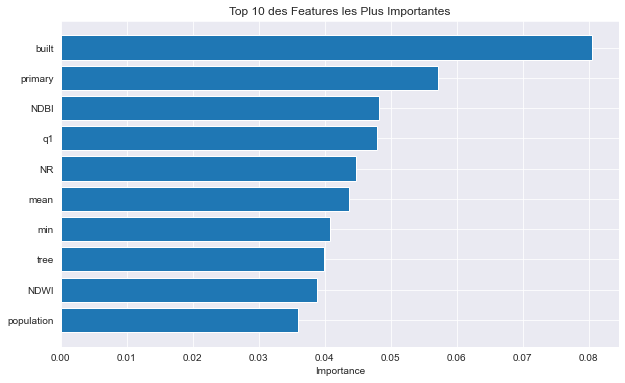

In [29]:
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.xlabel("Importance")
plt.title("Top 10 des Features les Plus Importantes")
plt.gca().invert_yaxis()
plt.show()

In [30]:
features = doubs_train.drop(columns=["duree_minutes", "hex_id", "proches_voisins", 'geometry', 'centroid']).columns
target = "duree_minutes"

X_train = doubs_train[features]
y_train = doubs_train[target]
X_test = doubs_test[features]
y_test = doubs_test[target]

xgb_model = XGBRegressor(objective="reg:squarederror")

param_grid = {
    "n_estimators": [100, 300, 500],   # Nombre d'arbres
    "max_depth": [4, 6, 8],            # Profondeur des arbres
    "learning_rate": [0.01, 0.1, 0.3], # Taux d’apprentissage
    "subsample": [0.8, 1],             # Sous-échantillonnage
    "colsample_bytree": [0.8, 1],      # Pourcentage de colonnes utilisées par arbre
    "gamma": [0, 0.1, 0.3]             # Pénalisation des nouvelles feuilles
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)

best_model = XGBRegressor(**grid_search.best_params_, objective="reg:squarederror")
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R²: {r2}")

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Meilleurs paramètres : {'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
MSE: 2267.36772185648
RMSE: 47.61688483990191
MAE: 33.68816797280778
R²: -0.1399716298364717


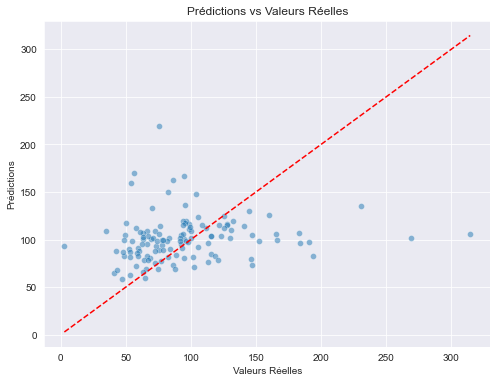

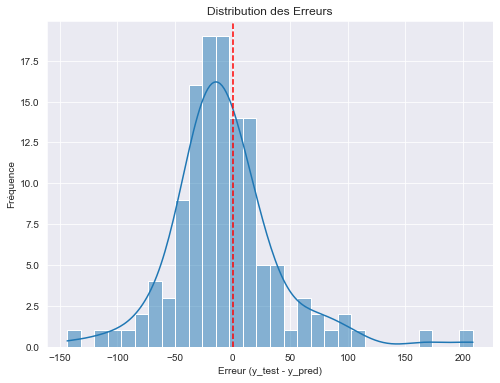

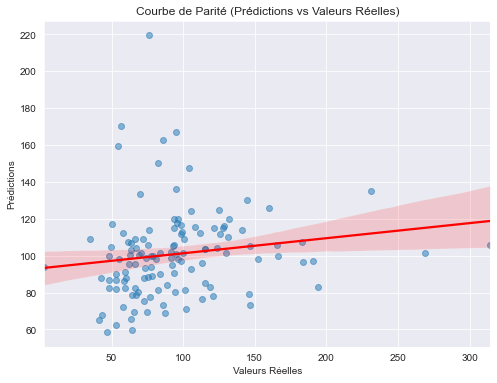

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Valeurs Réelles")
plt.show()

errors = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Fréquence")
plt.title("Distribution des Erreurs")
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.xlabel("Valeurs Réelles")
plt.ylabel("Prédictions")
plt.title("Courbe de Parité (Prédictions vs Valeurs Réelles)")
plt.show()

In [32]:
best_params = {
    "colsample_bytree": 0.8,
    "gamma": 0,
    "learning_rate": 0.01,
    "max_depth": 4,
    "n_estimators": 300,
    "subsample": 0.8
}

X_train = doubs_train.drop(columns=["duree_minutes", "hex_id", "proches_voisins", 'geometry', 'centroid'])
y_train = doubs_train["duree_minutes"]
X_test = doubs_test.drop(columns=["duree_minutes", "hex_id", "proches_voisins", 'geometry', 'centroid'])
y_test = doubs_test["duree_minutes"]

model = XGBRegressor(**best_params, objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R²: {r2}")

MSE: 2265.819351772052
RMSE: 47.60062343890101
MAE: 34.07080175121336
R²: -0.13919315091939066


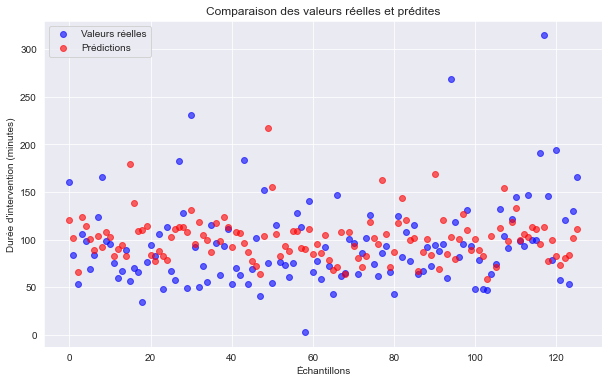

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test)), y_test, color="blue", label="Valeurs réelles", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred, color="red", label="Prédictions", alpha=0.6)

plt.xlabel("Échantillons")
plt.ylabel("Durée d'intervention (minutes)")
plt.title("Comparaison des valeurs réelles et prédites")
plt.legend()
plt.show()

In [34]:
hex_random = doubs_train.sample(1).iloc[0]

hex_geom = hex_random.geometry

aire = hex_geom.area
perimetre = hex_geom.length

coords = list(hex_geom.exterior.coords[:-1])

diagonale = max(
    [Point(p1).distance(Point(p2)) for p1, p2 in combinations(coords, 2)]
)

print(f"Hexagone sélectionné : {hex_random.hex_id}")
print(f"Aire : {aire:.2f} m²")
print(f"Périmètre : {perimetre:.2f} m")
print(f"Diagonale : {diagonale:.2f} m")

Hexagone sélectionné : 871f8216affffff
Aire : 4861681.65 m²
Périmètre : 8218.43 m
Diagonale : 2852.36 m
